In [1]:
#Importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#Reading data-sets
df = pd.read_csv(r"F:\data analyst projects\telecom_churn.csv")

In [9]:
df.sample(5)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
680,0,116,1,0,0.00,1,189.5,90,49.0,9.49,13.1
137,0,91,1,0,0.00,3,203.1,106,53.0,10.51,12.0
2205,0,110,1,0,0.00,3,151.8,106,38.0,6.90,11.2
2020,0,108,1,0,0.00,2,240.2,78,61.0,11.52,5.2
1995,0,118,1,1,3.16,1,256.3,119,97.6,12.91,11.7


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


**Basic Checkings for data sets**

In [14]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [15]:
df.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [16]:
df.drop_duplicates(inplace=True)

**Doing Some Feature Engineering**

In [20]:
# 1. Average Call Duration
df['AvgCallDuration'] = df['DayMins'] / df['DayCalls']

In [21]:
# 2. Total Usage (customer engagement)
df['TotalUsage'] = df['DayMins'] + df['RoamMins']

In [22]:
# 3. Cost per Minute (pricing pressure)
df['CostPerMin'] = df['MonthlyCharge'] / (df['DayMins'] + 1)

In [23]:
# 4. High Service Calls Flag (customer dissatisfaction)
df['HighServiceCalls'] = df['CustServCalls'].apply(lambda x: 1 if x >= 3 else 0)

In [24]:
# 5. Heavy User Flag
df['HeavyUser'] = df['TotalUsage'].apply(lambda x: 1 if x > df['TotalUsage'].median() else 0)

In [25]:
df

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,AvgCallDuration,TotalUsage,CostPerMin,HighServiceCalls,HeavyUser
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0,2.410000,275.1,0.334461,0,1
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7,1.313821,175.3,0.504305,0,0
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2,2.135088,255.6,0.212766,0,1
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6,4.216901,306.0,0.189747,0,1
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1,1.475221,176.8,0.244484,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9,2.028571,166.1,0.456107,0,0
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6,4.054386,240.7,0.242999,1,1
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1,1.658716,194.9,0.308031,0,1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0,2.036190,218.8,0.232775,0,1


**Plotting Some Visuals**

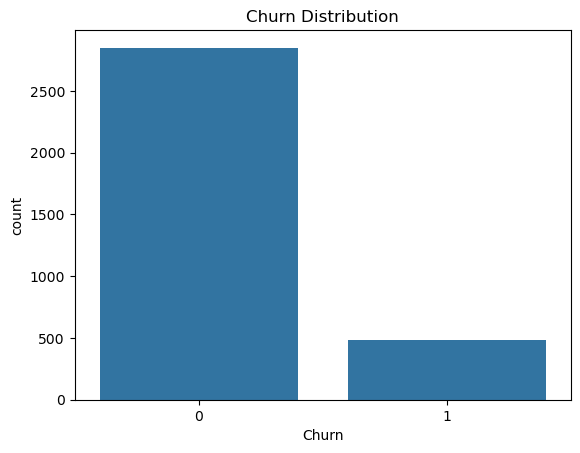

In [26]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

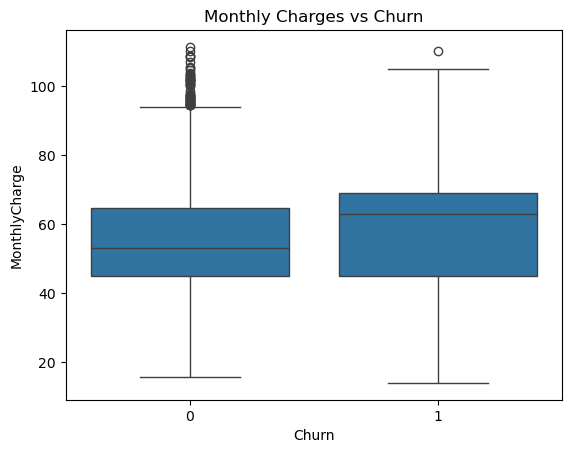

In [27]:
sns.boxplot(x='Churn', y='MonthlyCharge', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

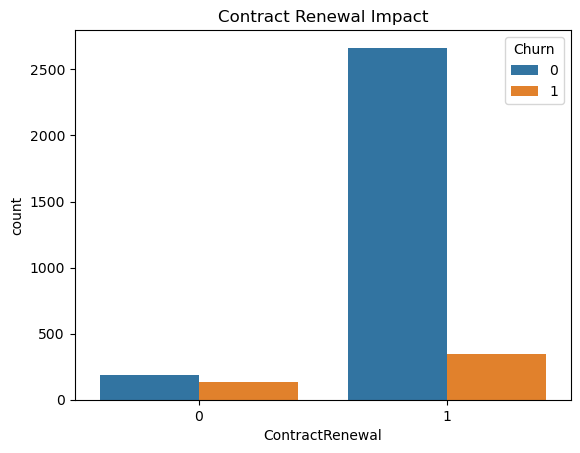

In [28]:
sns.countplot(x='ContractRenewal', hue='Churn', data=df)
plt.title("Contract Renewal Impact")
plt.show()

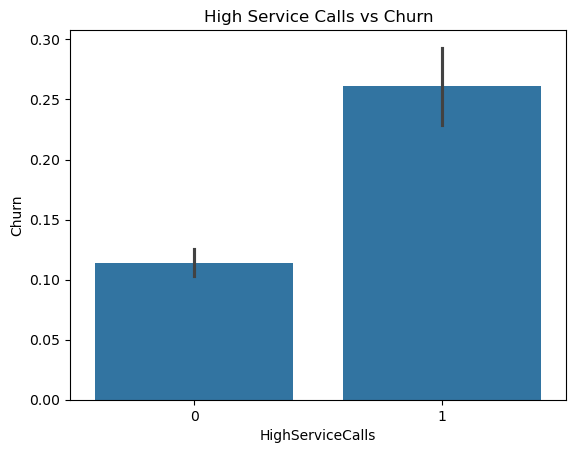

In [29]:
sns.barplot(x='HighServiceCalls', y='Churn', data=df)
plt.title("High Service Calls vs Churn")
plt.show()

In [30]:
churn_rate = df['Churn'].mean() * 100
print("Churn Rate:", churn_rate)

Churn Rate: 14.491449144914492


In [31]:
df.groupby('ContractRenewal')['Churn'].mean() * 100

ContractRenewal
0    42.414861
1    11.495017
Name: Churn, dtype: float64

In [32]:
df['CustomerSegment'] = df['MonthlyCharge'].apply(
    lambda x: 'Low' if x < 50 else ('Medium' if x < 80 else 'High')
)

In [33]:
df.groupby('CustomerSegment')['Churn'].mean() * 100

CustomerSegment
High      10.315186
Low       11.705426
Medium    17.473436
Name: Churn, dtype: float64

In [35]:
df['CustomerSegment'] = df['CustomerSegment'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [36]:
df

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,AvgCallDuration,TotalUsage,CostPerMin,HighServiceCalls,HeavyUser,CustomerSegment
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0,2.410000,275.1,0.334461,0,1,2
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7,1.313821,175.3,0.504305,0,0,2
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2,2.135088,255.6,0.212766,0,1,1
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6,4.216901,306.0,0.189747,0,1,1
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1,1.475221,176.8,0.244484,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9,2.028571,166.1,0.456107,0,0,1
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6,4.054386,240.7,0.242999,1,1,1
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1,1.658716,194.9,0.308031,0,1,1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0,2.036190,218.8,0.232775,0,1,1


In [37]:
summary = df.groupby('Churn').agg({
    'MonthlyCharge': 'mean',
    'CustServCalls': 'mean',
    'TotalUsage': 'mean'
})
print(summary)

       MonthlyCharge  CustServCalls  TotalUsage
Churn                                          
0          55.816246       1.449825  185.334632
1          59.190062       2.229814  217.614079


In [38]:
df

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,AvgCallDuration,TotalUsage,CostPerMin,HighServiceCalls,HeavyUser,CustomerSegment
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0,2.410000,275.1,0.334461,0,1,2
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7,1.313821,175.3,0.504305,0,0,2
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2,2.135088,255.6,0.212766,0,1,1
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6,4.216901,306.0,0.189747,0,1,1
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1,1.475221,176.8,0.244484,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9,2.028571,166.1,0.456107,0,0,1
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6,4.054386,240.7,0.242999,1,1,1
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1,1.658716,194.9,0.308031,0,1,1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0,2.036190,218.8,0.232775,0,1,1
